In [63]:
params <- list(
    ps_raw = "data/temp/ps_raw.rds",
    ps_core = "data/temp/ps_core.rds",
    euc_dist_core = "results/ASVs_euclidean_core_distance.tsv"
)

In [64]:
set.seed(8092003)

In [65]:
library(phyloseq)
library(dplyr)
library(microbiome)

In [66]:
ps_raw <- readRDS(params$ps_raw)
ps_core <- readRDS(params$ps_core)
ps_core <- prune_taxa(taxa_sums(ps_core) > 0, ps_core)
meta <- data.frame(sample_data(ps_core))

In [67]:
source("workflow/scripts/asv_vst_normalization.R")

In [68]:
vst_res <- vst_normalization(ps_core)
ps_core_vst <- vst_res$ps_vst
euc_dist_core <- vst_res$euclidean_dist

converting counts to integer mode

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.



In [69]:
microbiome::summarize_phyloseq(ps_raw)
ntaxa(ps_raw)
ps_raw

Compositional = NO2



1] Min. number of reads = 4172] Max. number of reads = 1004533] Total number of reads = 23953814] Average number of reads = 29211.96341463415] Median number of reads = 26973.57] Sparsity = 0.8848441644408856] Any OTU sum to 1 or less? YES8] Number of singletons = 10929] Percent of OTUs that are singletons 
        (i.e. exactly one read detected across all samples)20.724995255266710] Number of sample variables are: 62ID_KYHhcd_dated_sexd_age_hcd_age_hc_grp_10yrd_age_hc_grp_5yrb_a9bd_education3_vsbd_phq9_sev_scorebd_phq9_dep_altbd_phq9_symptomcountbd_phq9_dep_catbd_phq9_any_depbd_phq9_mod_depb_e1b_e2b_e3b_e4b_e5b_e6b_e7b_e8b_e9b_e10lab_lc_w8lab_lc_w8blab_lc_w8ahc_c1hcd_c2g_g4hcd_c2g5hcd_c2g_f5hcd_c2g_g5hcd_c2g6hcd_c2g_f6hcd_c2g_g6hcd_c2g7hcd_c2g_f7hcd_c2g_g7hcd_c2g1hcd_c2g_f1hcd_c2g_g1hcd_c2g2hcd_c2g_f2hcd_c2g_g2hcd_c2g3hcd_c2g_f3hcd_c2g_g3hcd_c2g4hcd_c2g_f4atc1atc2atc3atc4atc5atc6atc7antidepressant_usageantibiotics_usageseasondepr_or_controlbatchnew_id2



[[1]]
[1] "1] Min. number of reads = 417"

[[2]]
[1] "2] Max. number of reads = 100453"

[[3]]
[1] "3] Total number of reads = 2395381"

[[4]]
[1] "4] Average number of reads = 29211.9634146341"

[[5]]
[1] "5] Median number of reads = 26973.5"

[[6]]
[1] "7] Sparsity = 0.884844164440885"

[[7]]
[1] "6] Any OTU sum to 1 or less? YES"

[[8]]
[1] "8] Number of singletons = 1092"

[[9]]
[1] "9] Percent of OTUs that are singletons \n        (i.e. exactly one read detected across all samples)20.7249952552667"

[[10]]
[1] "10] Number of sample variables are: 62"

[[11]]
 [1] "ID_KYH"               "hcd_date"             "d_sex"               
 [4] "d_age_hc"             "d_age_hc_grp_10yr"    "d_age_hc_grp_5yr"    
 [7] "b_a9"                 "bd_education3_vs"     "bd_phq9_sev_score"   
[10] "bd_phq9_dep_alt"      "bd_phq9_symptomcount" "bd_phq9_dep_cat"     
[13] "bd_phq9_any_dep"      "bd_phq9_mod_dep"      "b_e1"                
[16] "b_e2"                 "b_e3"                 "b_e4"                
[19] "b_e5"                 "b_e6"                 "b_e7"                
[22] "b_e8"                 "b_e9"                 "b_e10"               
[25] "lab_lc_w8"            "lab_lc_w8b"           "lab_lc_w8a"          
[28] "hc_c1"                "hcd_c2g_g4"           "hcd_c2g5"            
[31] "hcd_c2g_f5"           "hcd_c2g_g5"           "hcd_c2g6"            
[34] "hcd_c2g_f6"           "hcd_c2g_g6"           "hcd_c2g7"            
[37] "hcd_c2g_f7"           "hcd_c2g_g7"           "hcd_c2g1"            
[40] "hcd_c2g_f1"           "hcd_c2g_g1"           "hcd_c2g2"            
[43] "hcd_c2g_f2"           "hcd_c2g_g2"           "hcd_c2g3"            
[46] "hcd_c2g_f3"           "hcd_c2g_g3"           "hcd_c2g4"            
[49] "hcd_c2g_f4"           "atc1"                 "atc2"                
[52] "atc3"                 "atc4"                 "atc5"                
[55] "atc6"                 "atc7"                 "antidepressant_usage"
[58] "antibiotics_usage"    "season"               "depr_or_control"     
[61] "batch"                "new_id"

[1] 5269

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 5269 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 5269 taxa by 7 taxonomic ranks ]

In [70]:
microbiome::summarize_phyloseq(ps_core)
ntaxa(ps_core)
ps_core

Compositional = NO2

1] Min. number of reads = 4012] Max. number of reads = 858363] Total number of reads = 22387074] Average number of reads = 27301.30487804885] Median number of reads = 250647] Sparsity = 0.7189451429531526] Any OTU sum to 1 or less? NO8] Number of singletons = 09] Percent of OTUs that are singletons 
        (i.e. exactly one read detected across all samples)010] Number of sample variables are: 62ID_KYHhcd_dated_sexd_age_hcd_age_hc_grp_10yrd_age_hc_grp_5yrb_a9bd_education3_vsbd_phq9_sev_scorebd_phq9_dep_altbd_phq9_symptomcountbd_phq9_dep_catbd_phq9_any_depbd_phq9_mod_depb_e1b_e2b_e3b_e4b_e5b_e6b_e7b_e8b_e9b_e10lab_lc_w8lab_lc_w8blab_lc_w8ahc_c1hcd_c2g_g4hcd_c2g5hcd_c2g_f5hcd_c2g_g5hcd_c2g6hcd_c2g_f6hcd_c2g_g6hcd_c2g7hcd_c2g_f7hcd_c2g_g7hcd_c2g1hcd_c2g_f1hcd_c2g_g1hcd_c2g2hcd_c2g_f2hcd_c2g_g2hcd_c2g3hcd_c2g_f3hcd_c2g_g3hcd_c2g4hcd_c2g_f4atc1atc2atc3atc4atc5atc6atc7antidepressant_usageantibiotics_usageseasondepr_or_controlbatchnew_id2



[[1]]
[1] "1] Min. number of reads = 401"

[[2]]
[1] "2] Max. number of reads = 85836"

[[3]]
[1] "3] Total number of reads = 2238707"

[[4]]
[1] "4] Average number of reads = 27301.3048780488"

[[5]]
[1] "5] Median number of reads = 25064"

[[6]]
[1] "7] Sparsity = 0.718945142953152"

[[7]]
[1] "6] Any OTU sum to 1 or less? NO"

[[8]]
[1] "8] Number of singletons = 0"

[[9]]
[1] "9] Percent of OTUs that are singletons \n        (i.e. exactly one read detected across all samples)0"

[[10]]
[1] "10] Number of sample variables are: 62"

[[11]]
 [1] "ID_KYH"               "hcd_date"             "d_sex"               
 [4] "d_age_hc"             "d_age_hc_grp_10yr"    "d_age_hc_grp_5yr"    
 [7] "b_a9"                 "bd_education3_vs"     "bd_phq9_sev_score"   
[10] "bd_phq9_dep_alt"      "bd_phq9_symptomcount" "bd_phq9_dep_cat"     
[13] "bd_phq9_any_dep"      "bd_phq9_mod_dep"      "b_e1"                
[16] "b_e2"                 "b_e3"                 "b_e4"                
[19] "b_e5"                 "b_e6"                 "b_e7"                
[22] "b_e8"                 "b_e9"                 "b_e10"               
[25] "lab_lc_w8"            "lab_lc_w8b"           "lab_lc_w8a"          
[28] "hc_c1"                "hcd_c2g_g4"           "hcd_c2g5"            
[31] "hcd_c2g_f5"           "hcd_c2g_g5"           "hcd_c2g6"            
[34] "hcd_c2g_f6"           "hcd_c2g_g6"           "hcd_c2g7"            
[37] "hcd_c2g_f7"           "hcd_c2g_g7"           "hcd_c2g1"            
[40] "hcd_c2g_f1"           "hcd_c2g_g1"           "hcd_c2g2"            
[43] "hcd_c2g_f2"           "hcd_c2g_g2"           "hcd_c2g3"            
[46] "hcd_c2g_f3"           "hcd_c2g_g3"           "hcd_c2g4"            
[49] "hcd_c2g_f4"           "atc1"                 "atc2"                
[52] "atc3"                 "atc4"                 "atc5"                
[55] "atc6"                 "atc7"                 "antidepressant_usage"
[58] "antibiotics_usage"    "season"               "depr_or_control"     
[61] "batch"                "new_id"

[1] 1742

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1742 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 1742 taxa by 7 taxonomic ranks ]

In [71]:
meta$batch |> table()


B1 B2 
40 42 

In [72]:
predictors <- c(
    'depr_or_control', 
    # 'batch', 
    'd_sex', 
    'd_age_hc'
)
predictors <- predictors[meta[predictors] |> sapply(function(x) length(unique(x))) > 1]
rhs <- paste(predictors, collapse = " + ")
rhs

[1] "depr_or_control + d_sex + d_age_hc"

# Taxa overview

In [73]:
source("workflow/scripts/plots/dendrogram.R")

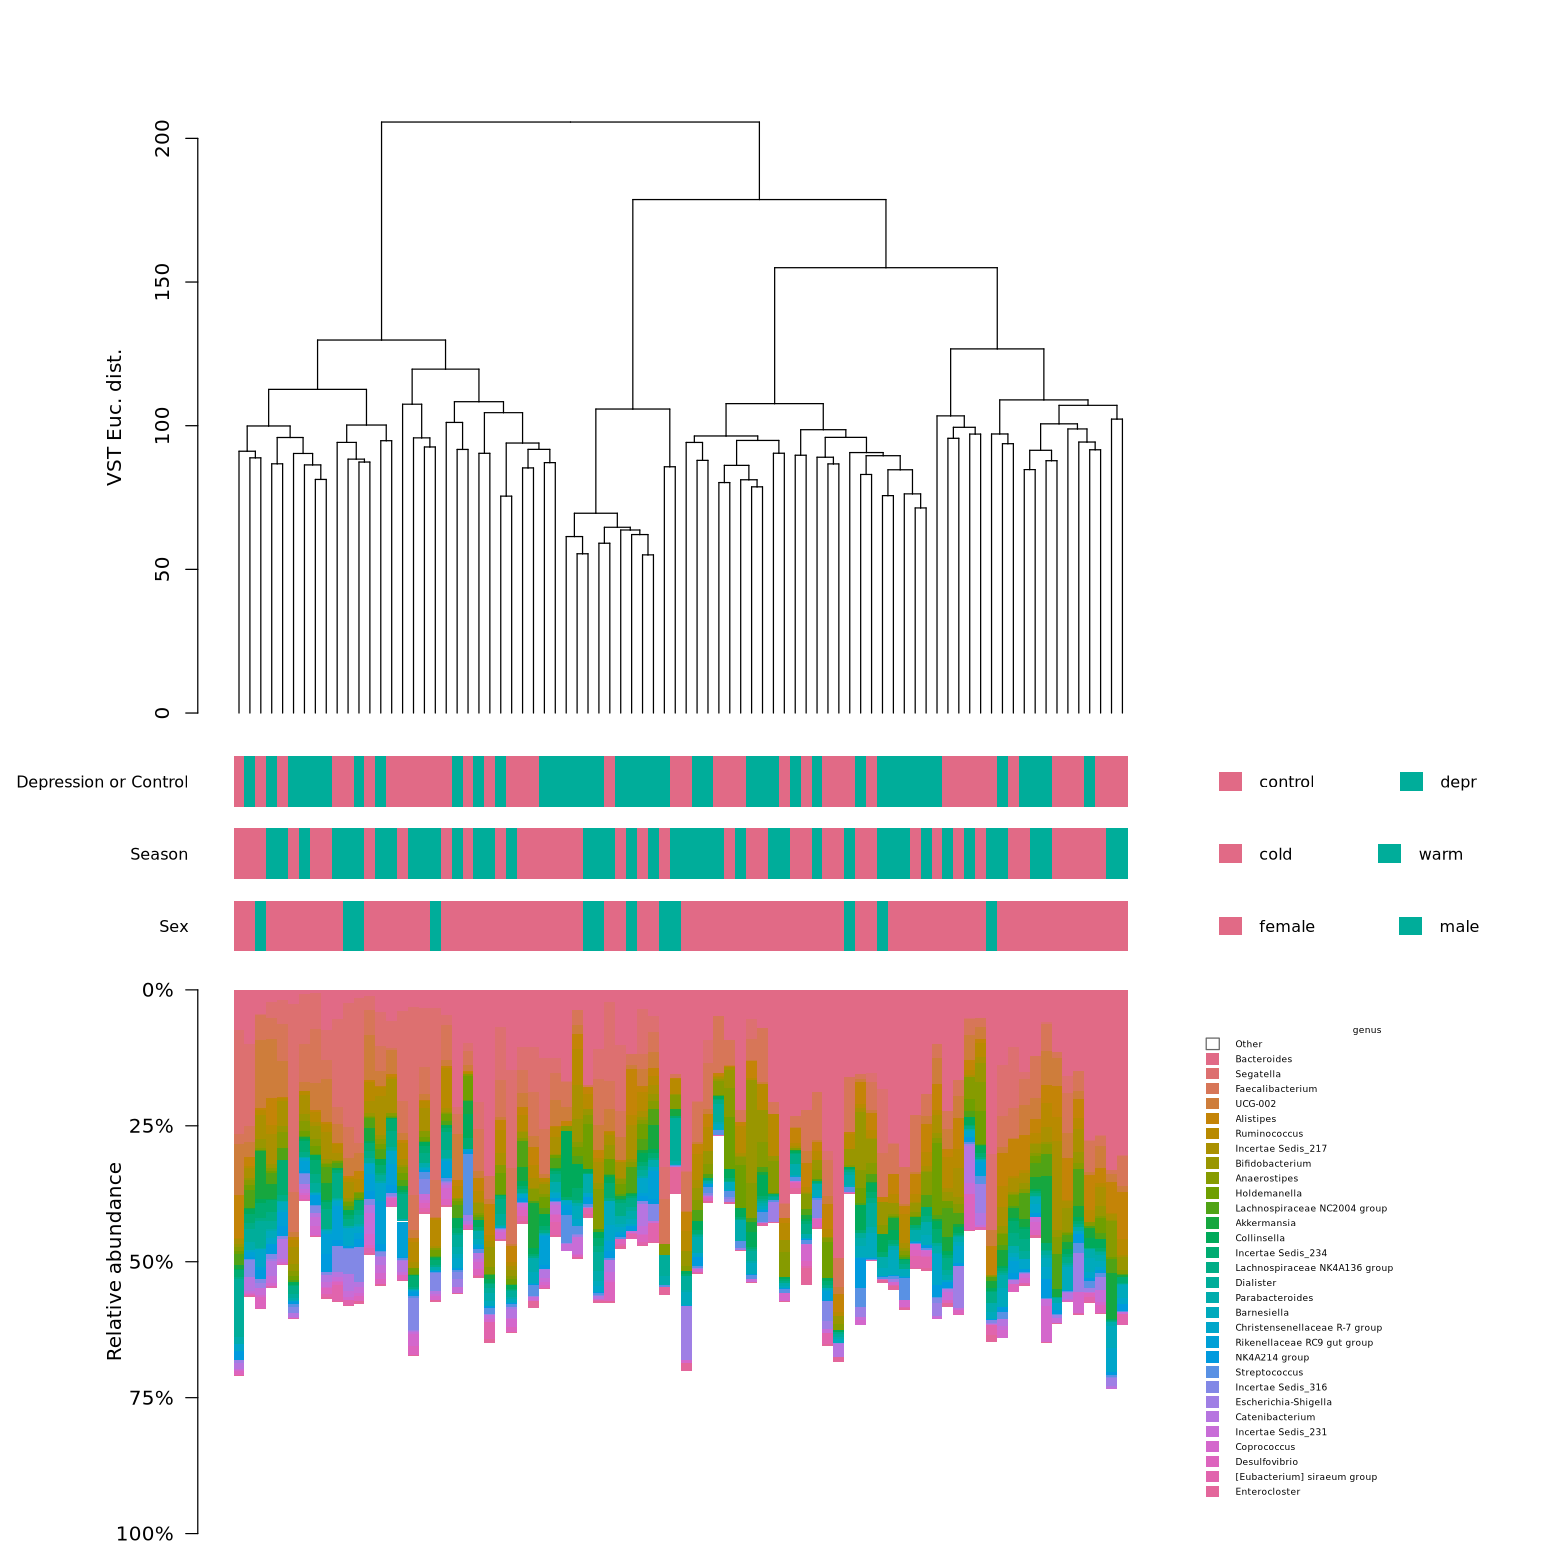

In [74]:
options(repr.plot.width = 13, repr.plot.height = 13)
plot_dendrogram(
    euc_dist_core, ps_core,
    'Depression or Control' = depr_or_control, Season = season, Sex = d_sex,
    taxa_rank = "genus", n_taxa = 30
)

# Beta diversity

## Ordination

Primary coordinates analysis (PCoA) on euclidean coordinate space. Ellipses - 1-SD interval (for bivar normal distr)

In [75]:
source("workflow/scripts/plots/pcoa.R")

## ASV-level

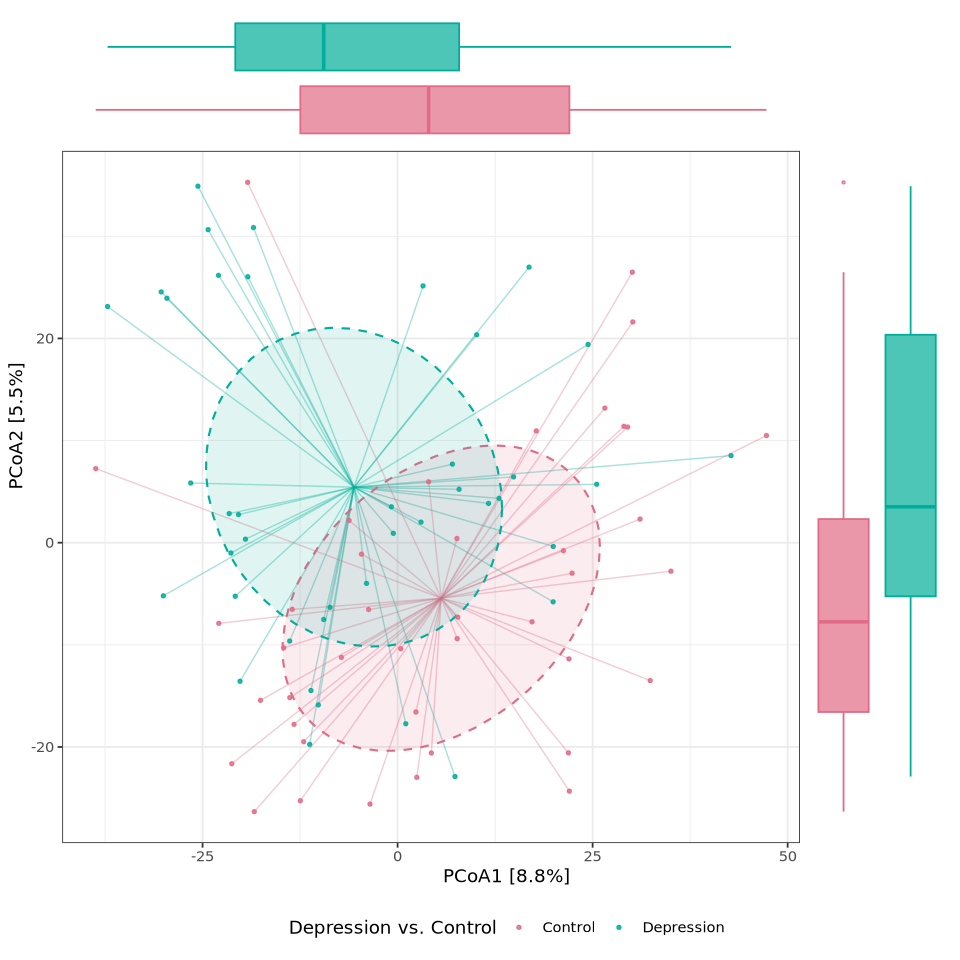

In [76]:
options(repr.plot.width = 8, repr.plot.height = 8)
dc_labels <- c(
    depr = "Depression",
    control = "Control"
)
ord_res <- plot_pcoa(ps_core_vst, euc_dist_core, 
    unname(dc_labels[depr_or_control]),
    legend_title="Depression vs. Control")
pcoa <- ord_res$pcoa

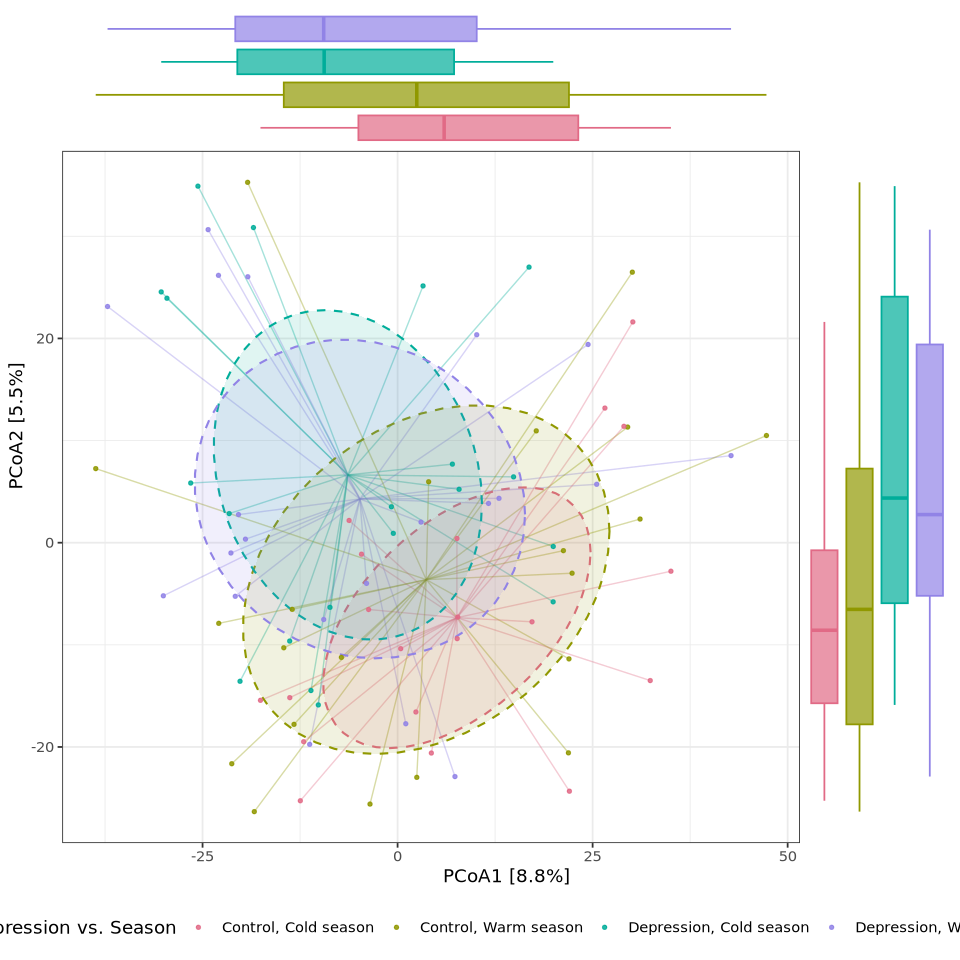

In [77]:
season_labels <- c(
    cold = 'Cold season',
    warm = 'Warm season'
)
plot_pcoa(ps_core_vst, euc_dist_core, paste(unname(dc_labels[depr_or_control]), unname(season_labels[season]), sep=", "), legend_title="Depression vs. Season")

In [78]:
scores <- as.data.frame(pcoa$points)
d2 <- mahalanobis(
    scores,
    colMeans(scores),
    cov(scores)
)
outliers <- which(
    d2 > qchisq(0.975, df = 2)
)

In [79]:
if (length(names(outliers)) == 0) {
    "There is no outlier samples"
} else {
    names(outliers)
}

[1] "There is no outlier samples"

### Stat

Test geterogenety of beta-diversity distributions with `vegan::betadisper`

In [80]:
library(vegan)

Firstly depression vs. control

In [81]:
dc_beta <- betadisper(euc_dist_core, sample_data(ps_core_vst)$depr_or_control)
dc_beta$group.distances |> t()

control,depr
70.30827,63.04693


Average distanses from sample to centers of the groups kindly the same (that likely proofs by same size of the ordination ellipses)

No test significance `vegan::anova`

In [82]:
anova(dc_beta, by='margin')

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,1080.902,1080.90224,22.45465,9.199973e-06
Residuals,80,3850.970,48.13712,NA,NA


So depression and control samples have heterogeneous dispersions, which means I cannot truly trust permanova test on whole set. But amount of samples are the same for depression and control sets. So premanova still valid choice

Use permutation analysis for difference (permanova) with `vegan::adonis2` 

In [83]:
set.seed(08092003)
form_string <- paste("euc_dist_core", "~", rhs)
f <- as.formula(form_string)
(dc_pmnv <- adonis2(f, meta, by = 'margin', permutations = 999))

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,7968.664,0.02112489,1.739646,0.003
d_sex,1,6651.404,0.01763284,1.452074,0.020
d_age_hc,1,5345.630,0.01417124,1.167009,0.106
Residual,78,357288.708,0.94717086,NA,NA
Total,81,377216.742,1.00000000,NA,NA


In [84]:
dc_pmnv['depr_or_control',c('R2', 'Pr(>F)')]

,R2,Pr(>F)
,<dbl>,<dbl>
depr_or_control,0.02112489,0.003


now test seasonal depression same way

In [85]:
paste(sample_data(ps_core)$depr_or_control, sample_data(ps_core)$season, sep="_") |> table() 


control_cold control_warm    depr_cold    depr_warm 
          20           21           20           21 

In [86]:
dc_labels <- c(
    depr = "Depression",
    control = "Control"
)
season_labels <- c(
    cold = 'Cold season',
    warm = 'Warm season'
)
(dc_freq <- unname(dc_labels[meta$depr_or_control]) |> table() |> data.frame())
(season_freq <- unname(season_labels[meta$season])  |> table() |> data.frame())
(sd_freq <- paste(unname(dc_labels[meta$depr_or_control]), unname(season_labels[meta$season]), sep=", ") |> table() |> data.frame())

(all_freq <- dplyr::bind_rows(dc_freq, season_freq, sd_freq))

Var1,Freq
<fct>,<int>
Control,41
Depression,41


Var1,Freq
<fct>,<int>
Cold season,40
Warm season,42


Var1,Freq
<fct>,<int>
"Control, Cold season",20
"Control, Warm season",21
"Depression, Cold season",20
"Depression, Warm season",21


Var1,Freq
<fct>,<int>
Control,41
Depression,41
Cold season,40
Warm season,42
"Control, Cold season",20
"Control, Warm season",21
"Depression, Cold season",20
"Depression, Warm season",21


In [87]:
seadepr_beta <- betadisper(euc_dist_core, paste(sample_data(ps_core)$depr_or_control, sample_data(ps_core)$season, sep="_"))
seadepr_beta$group.distances |> t()

control_cold,control_warm,depr_cold,depr_warm
68.31052,69.99188,61.8518,62.9626


In [88]:
set.seed(08092003)

form_string <- paste("euc_dist_core", "~", "season * ", rhs)
f <- as.formula(form_string)
f
(sd_pmnv <- adonis2(f, meta, permutations = 999, by = 'margin'))

euc_dist_core ~ season * depr_or_control + d_sex + d_age_hc

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d_sex,1,6338.982,0.01680461,1.3834774,0.029
d_age_hc,1,4865.460,0.01289832,1.0618827,0.268
season:depr_or_control,1,4543.142,0.01204385,0.9915369,0.443
Residual,76,348225.857,0.92314528,NA,NA
Total,81,377216.742,1.00000000,NA,NA


In [89]:
sd_pmnv['season:depr_or_control',]

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
season:depr_or_control,1,4543.142,0.01204385,0.9915369,0.443


## Genus level

Firstly aggregate up to genus level

In [90]:
ps_core_genus <- tax_glom(ps_core, taxrank = 'genus')
ps_core_genus

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 201 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 201 taxa by 7 taxonomic ranks ]

In [91]:
vst_core_genus <- vst_normalization(ps_core_genus)
ps_core_genus_vst <- vst_core_genus$ps_vst
euc_dist_core_genus <- vst_core_genus$euclidean_dist

converting counts to integer mode



In [92]:
ntaxa(ps_core_genus)

[1] 201

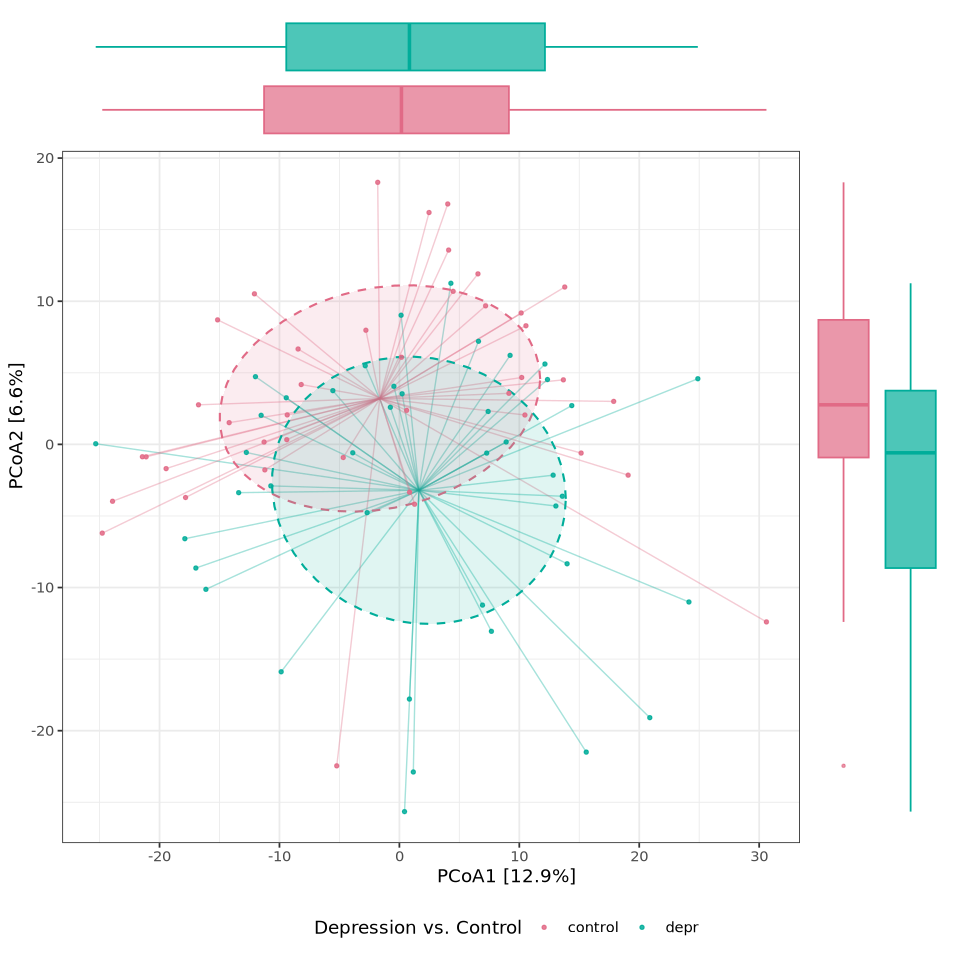

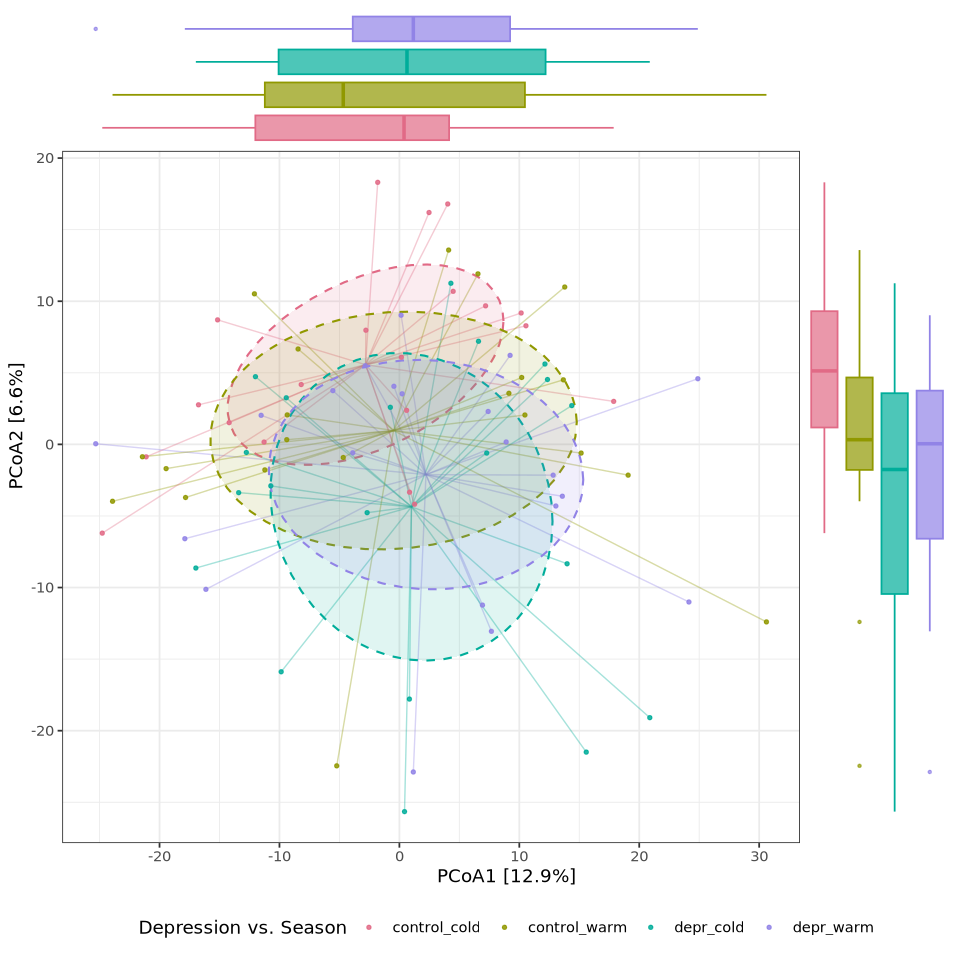

In [93]:
ord_res <- plot_pcoa(ps_core_genus_vst, euc_dist_core_genus, depr_or_control, legend_title="Depression vs. Control")
plot_pcoa(ps_core_genus_vst, euc_dist_core_genus, paste(depr_or_control, season, sep="_"), legend_title="Depression vs. Season")

### Stats

In [94]:
dc_beta_genus <- betadisper(euc_dist_core_genus, sample_data(ps_core_genus_vst)$depr_or_control)
dc_beta_genus$group.distances |> t()
anova(dc_beta_genus, by='margin')
set.seed(08092003)
form_string <- paste("euc_dist_core_genus", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

control,depr
34.87065,34.82283


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,4.689333e-02,0.04689333,0.002870934,0.9574025
Residuals,80,1.306706e+03,16.33382595,NA,NA


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,1767.143,0.01722577,1.418457,0.042
d_sex,1,2296.366,0.02238454,1.843256,0.009
d_age_hc,1,1343.124,0.01309252,1.078104,0.281
Residual,78,97173.997,0.94723361,NA,NA
Total,81,102587.150,1.00000000,NA,NA


In [95]:
dc_beta <- betadisper(euc_dist_core, sample_data(ps_core_vst)$depr_or_control)
sd_beta <- betadisper(euc_dist_core, paste(sample_data(ps_core)$depr_or_control, sample_data(ps_core)$season, sep="_"))
dc_beta_genus <- betadisper(euc_dist_core_genus, sample_data(ps_core_genus_vst)$depr_or_control)
sd_beta_genus <- betadisper(euc_dist_core, paste(sample_data(ps_core_genus_vst)$depr_or_control, sample_data(ps_core)$season, sep="_"))

In [96]:
(beta_p_df <- data.frame(
    'Groups' = c(
        'Depression vs. control. ASVs',
        'Depression vs. control. Genus',
        'Depression vs. season. ASVs',
        'Depression vs. season. Genus'
        ),
    'p-value' = sapply(
        list(dc_beta, sd_beta, dc_beta_genus, sd_beta_genus),
        function(bdr) anova(bdr, by='margin')['Groups', 'Pr(>F)']
    )
))

Groups,p.value
<chr>,<dbl>
Depression vs. control. ASVs,9.199973e-06
Depression vs. control. Genus,3.905632e-04
Depression vs. season. ASVs,9.574025e-01
Depression vs. season. Genus,3.905632e-04


In [97]:
seadepr_beta_genus <- betadisper(euc_dist_core, paste(sample_data(ps_core_genus_vst)$depr_or_control, sample_data(ps_core)$season, sep="_"))
seadepr_beta_genus$group.distances |> t()
anova(seadepr_beta_genus, by='margin')
set.seed(08092003)

form_string <- paste("euc_dist_core_genus", "~", "season * ", rhs)
f <- as.formula(form_string)
f
adonis2(f, meta, permutations = 999, by = 'margin')

control_cold,control_warm,depr_cold,depr_warm
68.31052,69.99188,61.8518,62.9626


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,3,975.8951,325.2984,6.80626,0.0003905632
Residuals,78,3727.9320,47.7940,NA,NA


euc_dist_core_genus ~ season * depr_or_control + d_sex + d_age_hc

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d_sex,1,2059.860,0.02007913,1.654871,0.017
d_age_hc,1,1290.033,0.01257500,1.036400,0.342
season:depr_or_control,1,1258.483,0.01226745,1.011052,0.428
Residual,76,94599.166,0.92213465,NA,NA
Total,81,102587.150,1.00000000,NA,NA


# Alpha

In [98]:
source('workflow/scripts/plots/alpha_violins.R')

## ASV level

In [99]:
ps_core_no_zero_taxa

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1742 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 1742 taxa by 7 taxonomic ranks ]

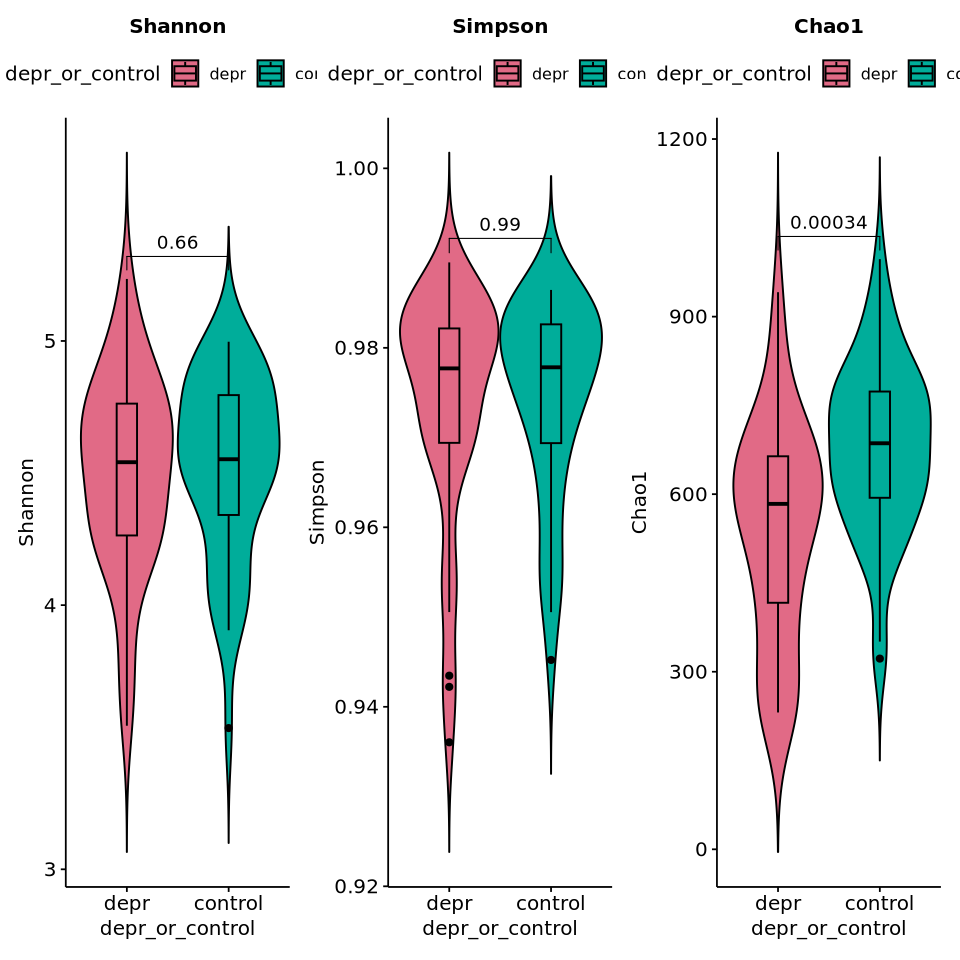

In [100]:
ps_core_no_zero_taxa <- prune_taxa(taxa_sums(ps_core) > 0, ps_core)
alpha <- estimate_richness(ps_core_no_zero_taxa, measures = c("Shannon", "Simpson", "Chao1"))
plot_alpha_violins(cbind(sample_data(ps_core), alpha), "depr_or_control",  c("Shannon", "Simpson", "Chao1"))

## Genus level

Warning message in wilcox.test.default(c(66.5, 115.857142857143, 118.428571428571, :
“cannot compute exact p-value with ties”


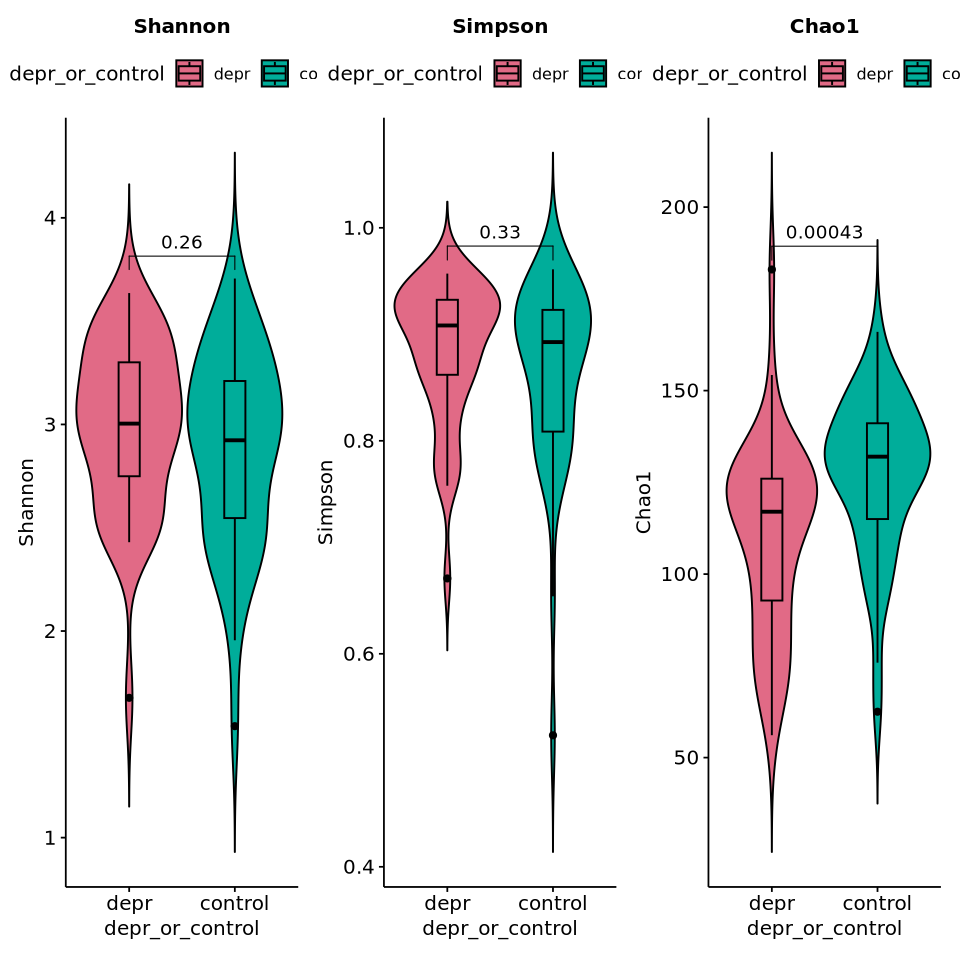

In [101]:
alpha <- estimate_richness(ps_core_genus, measures = c("Shannon", "Simpson", "Chao1"))
plot_alpha_violins(cbind(sample_data(ps_core_genus), alpha), 'depr_or_control', c("Shannon", "Simpson", "Chao1"))

# DMM (Dirichlet multinomial mixtures)

In [ ]:
library(DirichletMultinomial)

In [103]:
.qualitative <- DirichletMultinomial:::.qualitative

In [104]:
counts <- otu_table(ps_core_genus) |> t()

In [105]:
'#E16A86'

[1] "#E16A86"

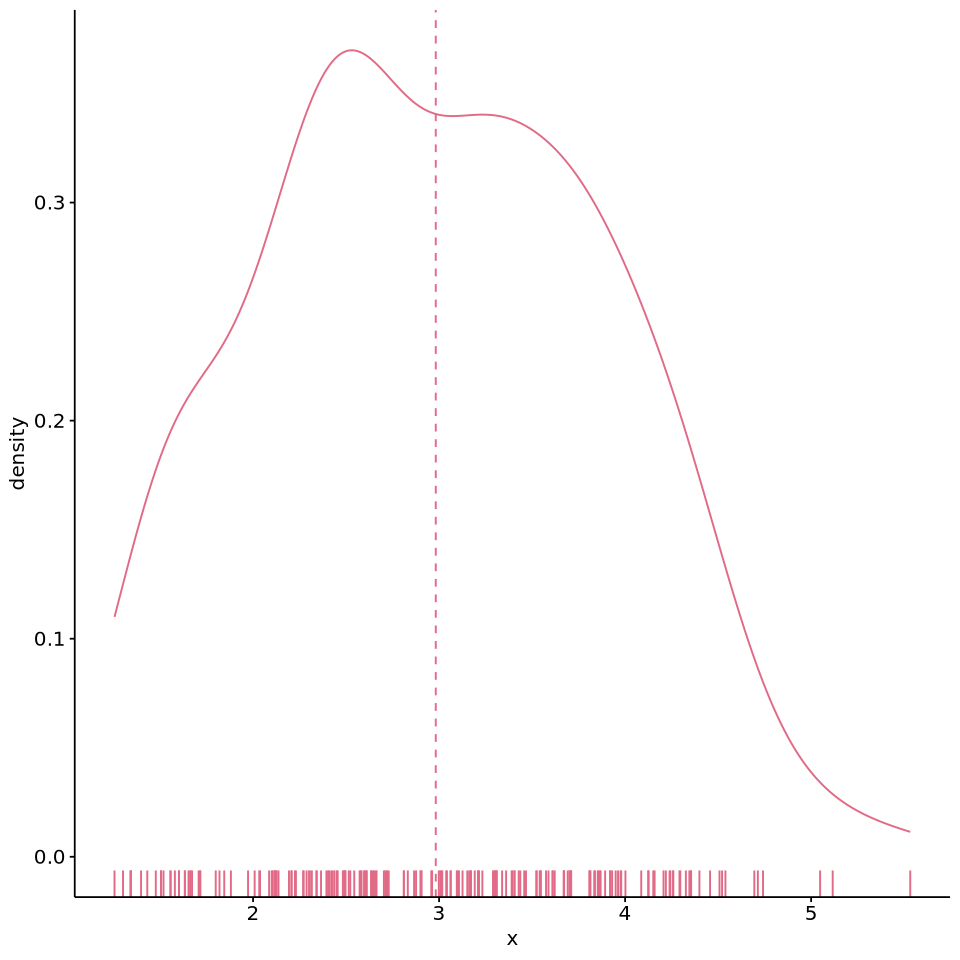

In [106]:
ggdensity(log10(colSums(counts)),
   add = "mean", rug = TRUE,
   color = hcl.colors(1, palette = "Dark 3"))

In [107]:
fit <- lapply(1:8, dmn, count=counts, verbose=TRUE)

dmn, k=1



  Soft kmeans
  Expectation Maximization setup
  Expectation Maximization
  Hessian


dmn, k=2



  Soft kmeans
    iteration 10 change 0.000203
    iteration 20 change 0.000001
  Expectation Maximization setup
  Expectation Maximization
    iteration 10 change 0.663464
    iteration 20 change 7.372419
    iteration 30 change 0.470306
    iteration 40 change 0.124153
  Hessian


dmn, k=3



...

dmn, k=4



  Soft kmeans
    iteration 10 change 0.004013
    iteration 20 change 0.001044
    iteration 30 change 0.000195
    iteration 40 change 0.000032
    iteration 50 change 0.000005
  Expectation Maximization setup
  Expectation Maximization
    iteration 10 change 10.060326
    iteration 20 change 9.333181
  Hessian


dmn, k=5



  Soft kmeans
    iteration 10 change 0.003857
    iteration 20 change 0.001397
    iteration 30 change 0.001726
    iteration 40 change 0.001719
    iteration 50 change 0.000628
    iteration 60 change 0.000165
    iteration 70 change 0.000043
    iteration 80 change 0.000011
    iteration 90 change 0.000003
  Expectation Maximization setup
  Expectation Maximization
    iteration 10 change 0.000023
  Hessian


dmn, k=6



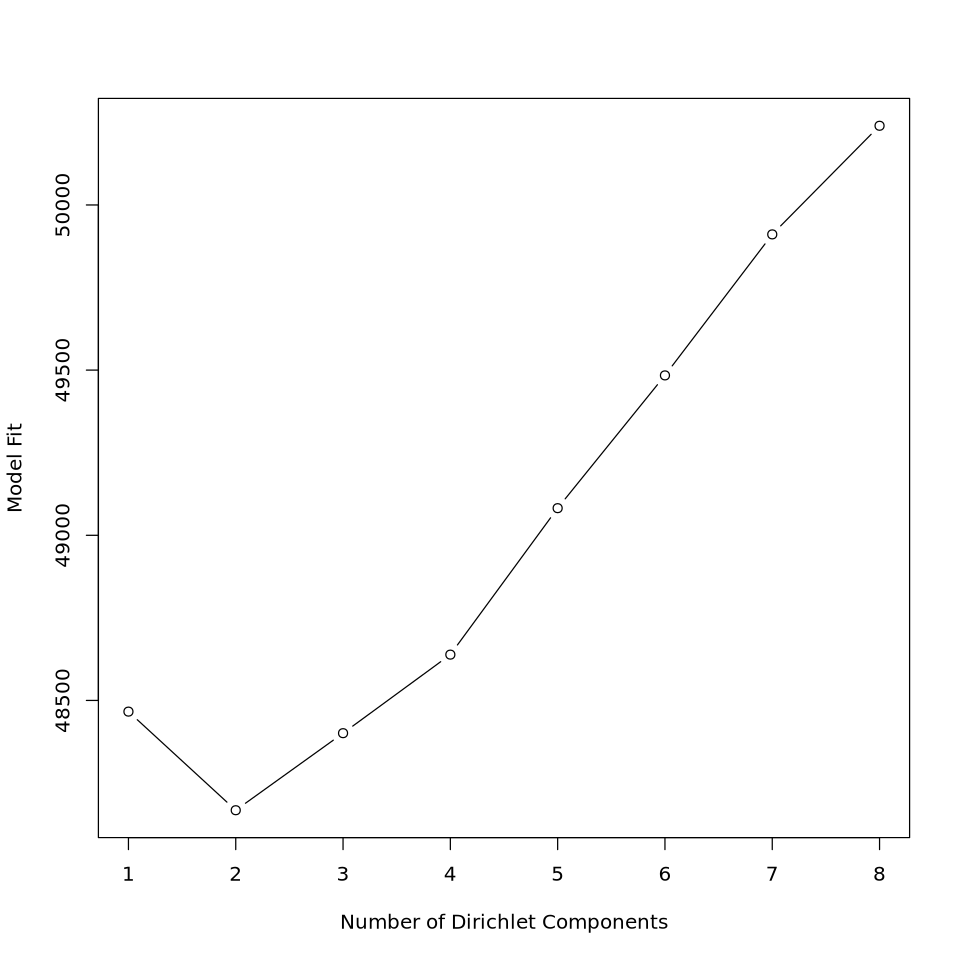

In [ ]:
lplc <- sapply(fit, laplace)
plot(lplc, type="b", xlab="Number of Dirichlet Components", ylab="Model Fit")

In [ ]:
(best <- fit[[which.min(lplc)]])

class: DMN 
k: 2 
samples x taxa: 82 x 201 
Laplace: 48167.64 BIC: 48890.1 AIC: 48405.14 

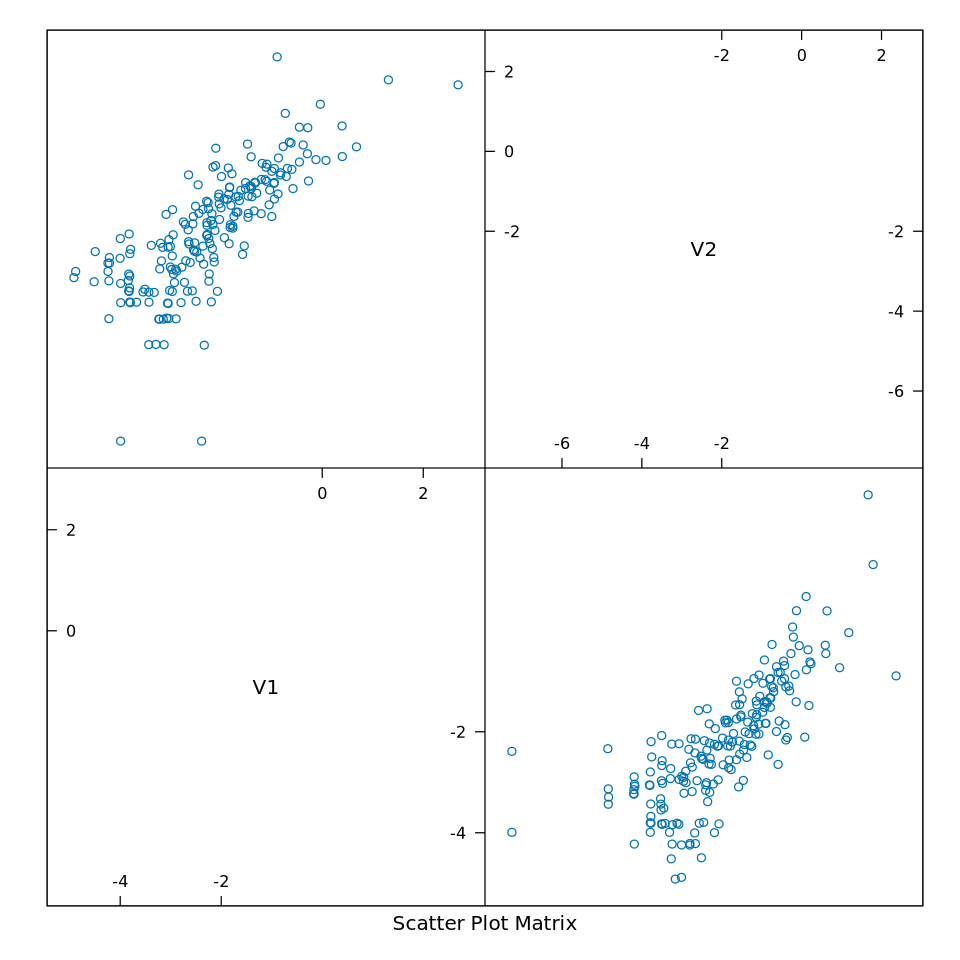

In [ ]:
splom(log(fitted(best)))

In [ ]:
source('workflow/scripts/fit_dmm.R')

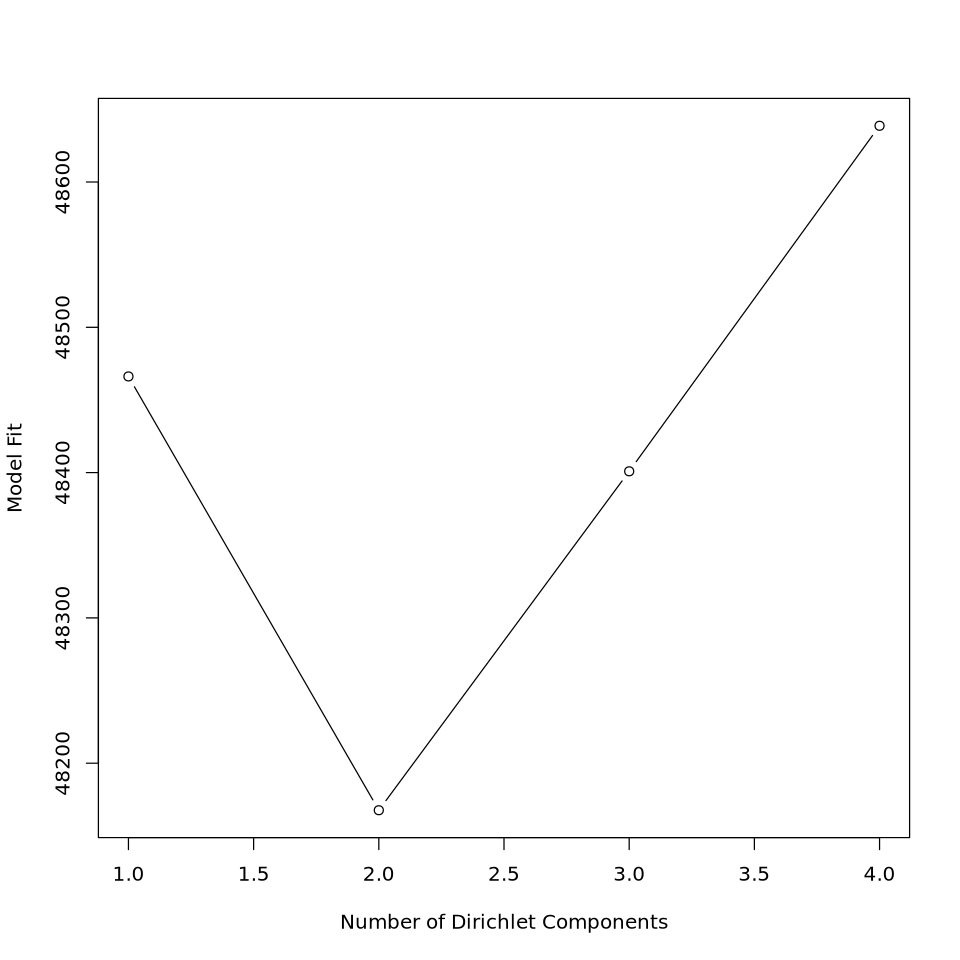

NULL


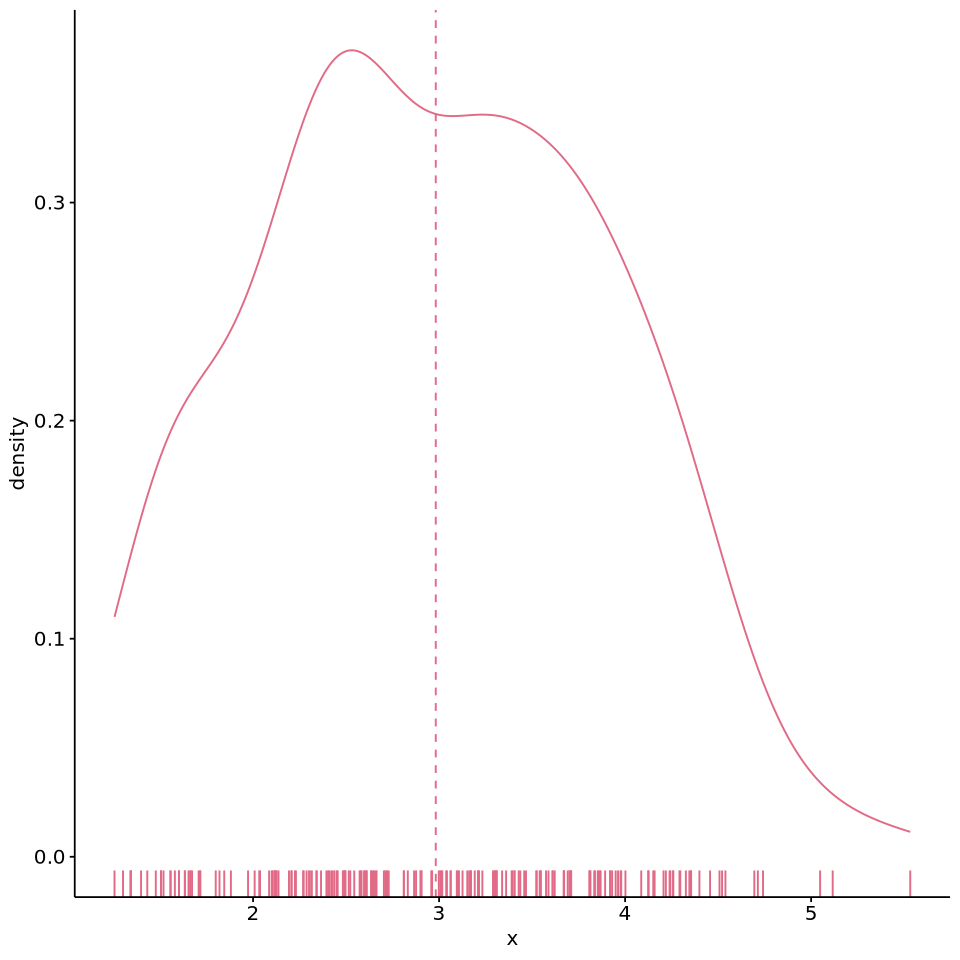

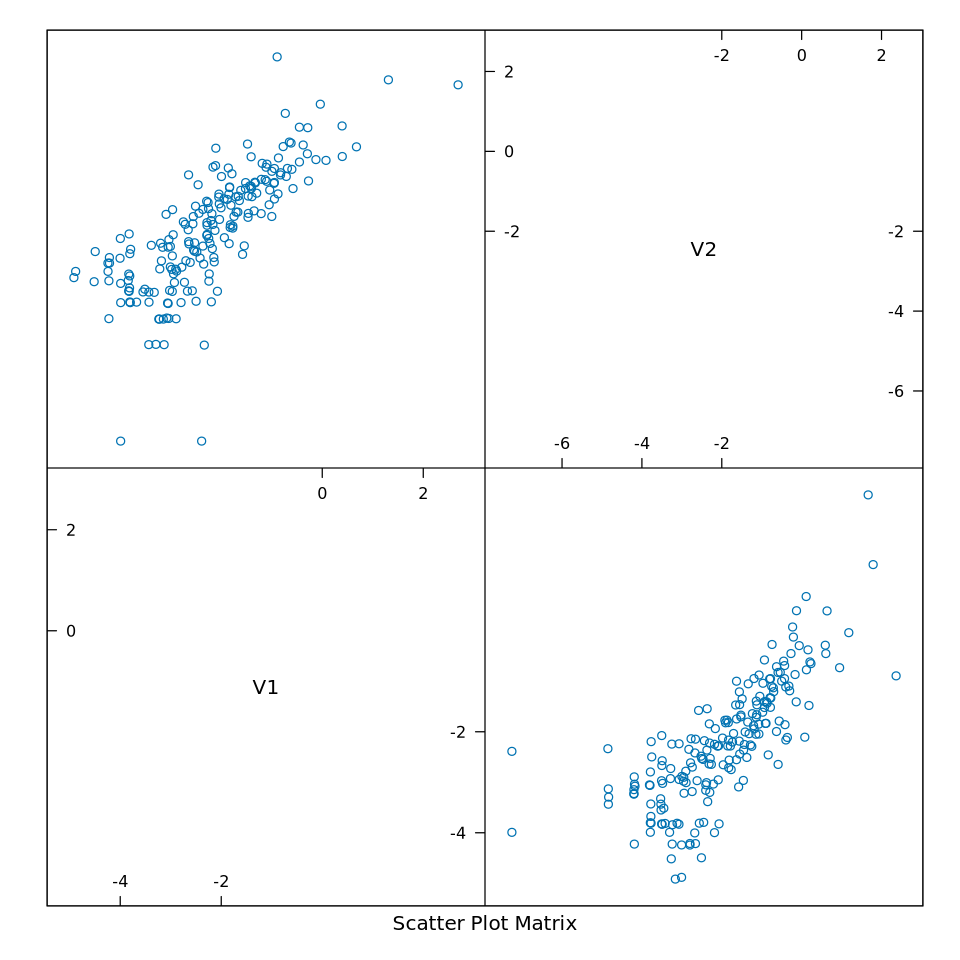

In [ ]:
ps_core_genus <- fit_dmm_from_ps(ps_core_genus, plots = 'show', max_components = 4)

In [ ]:
xtab <- xtabs(~ depr_or_control + dmm_cluster, data = data.frame(sample_data(ps_core_genus)))
xtab

               dmm_cluster
depr_or_control  1  2
        control 26 15
        depr    27 14

In [ ]:
chisq.test(xtab, simulate.p.value = T)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  xtab
X-squared = 0.053351, df = NA, p-value = 1


In [ ]:
fisher.test(xtab)


	Fisher's Exact Test for Count Data

data:  xtab
p-value = 1
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3291405 2.4483102
sample estimates:
odds ratio 
 0.8999374 


In [ ]:
form_string <- paste("dmm_cluster", "~", rhs)
f <- as.formula(form_string)
f

dmm_cluster ~ depr_or_control + d_sex + d_age_hc

In [ ]:

summary(model <- nnet::multinom(f, data = meta))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'summary': object 'dmm_cluster' not found


In [ ]:
car::Anova(model, type="III")

ERROR: Error: object 'model' not found


In [ ]:
sample_data(ps_core_genus) <- meta
sample_data(ps_core_genus_vst) <- meta
plot_pcoa(
    ps_core_genus_vst,
    euc_dist_core_genus, 
    dmm_cluster,
    legend_title="DMM: Depression vs. Season")

ERROR: Error: object 'dmm_cluster' not found


# Retest these results using CLR normalization and Bray-Curtis distances

In [ ]:
library(vegan)
library(phyloseq)
library(microbiome)

In [ ]:
set.seed(08092003)
ps_core_rare <- rarefy_even_depth(ps_core, rngseed = 08092003)

`set.seed(8092003)` was used to initialize repeatable random subsampling.

Please record this for your records so others can reproduce.

Try `set.seed(8092003); .Random.seed` for the full vector

...



356OTUs were removed because they are no longer 
present in any sample after random subsampling


...



In [ ]:
bray_dist_core <- phyloseq::distance(ps_core_rare, method = "bray")

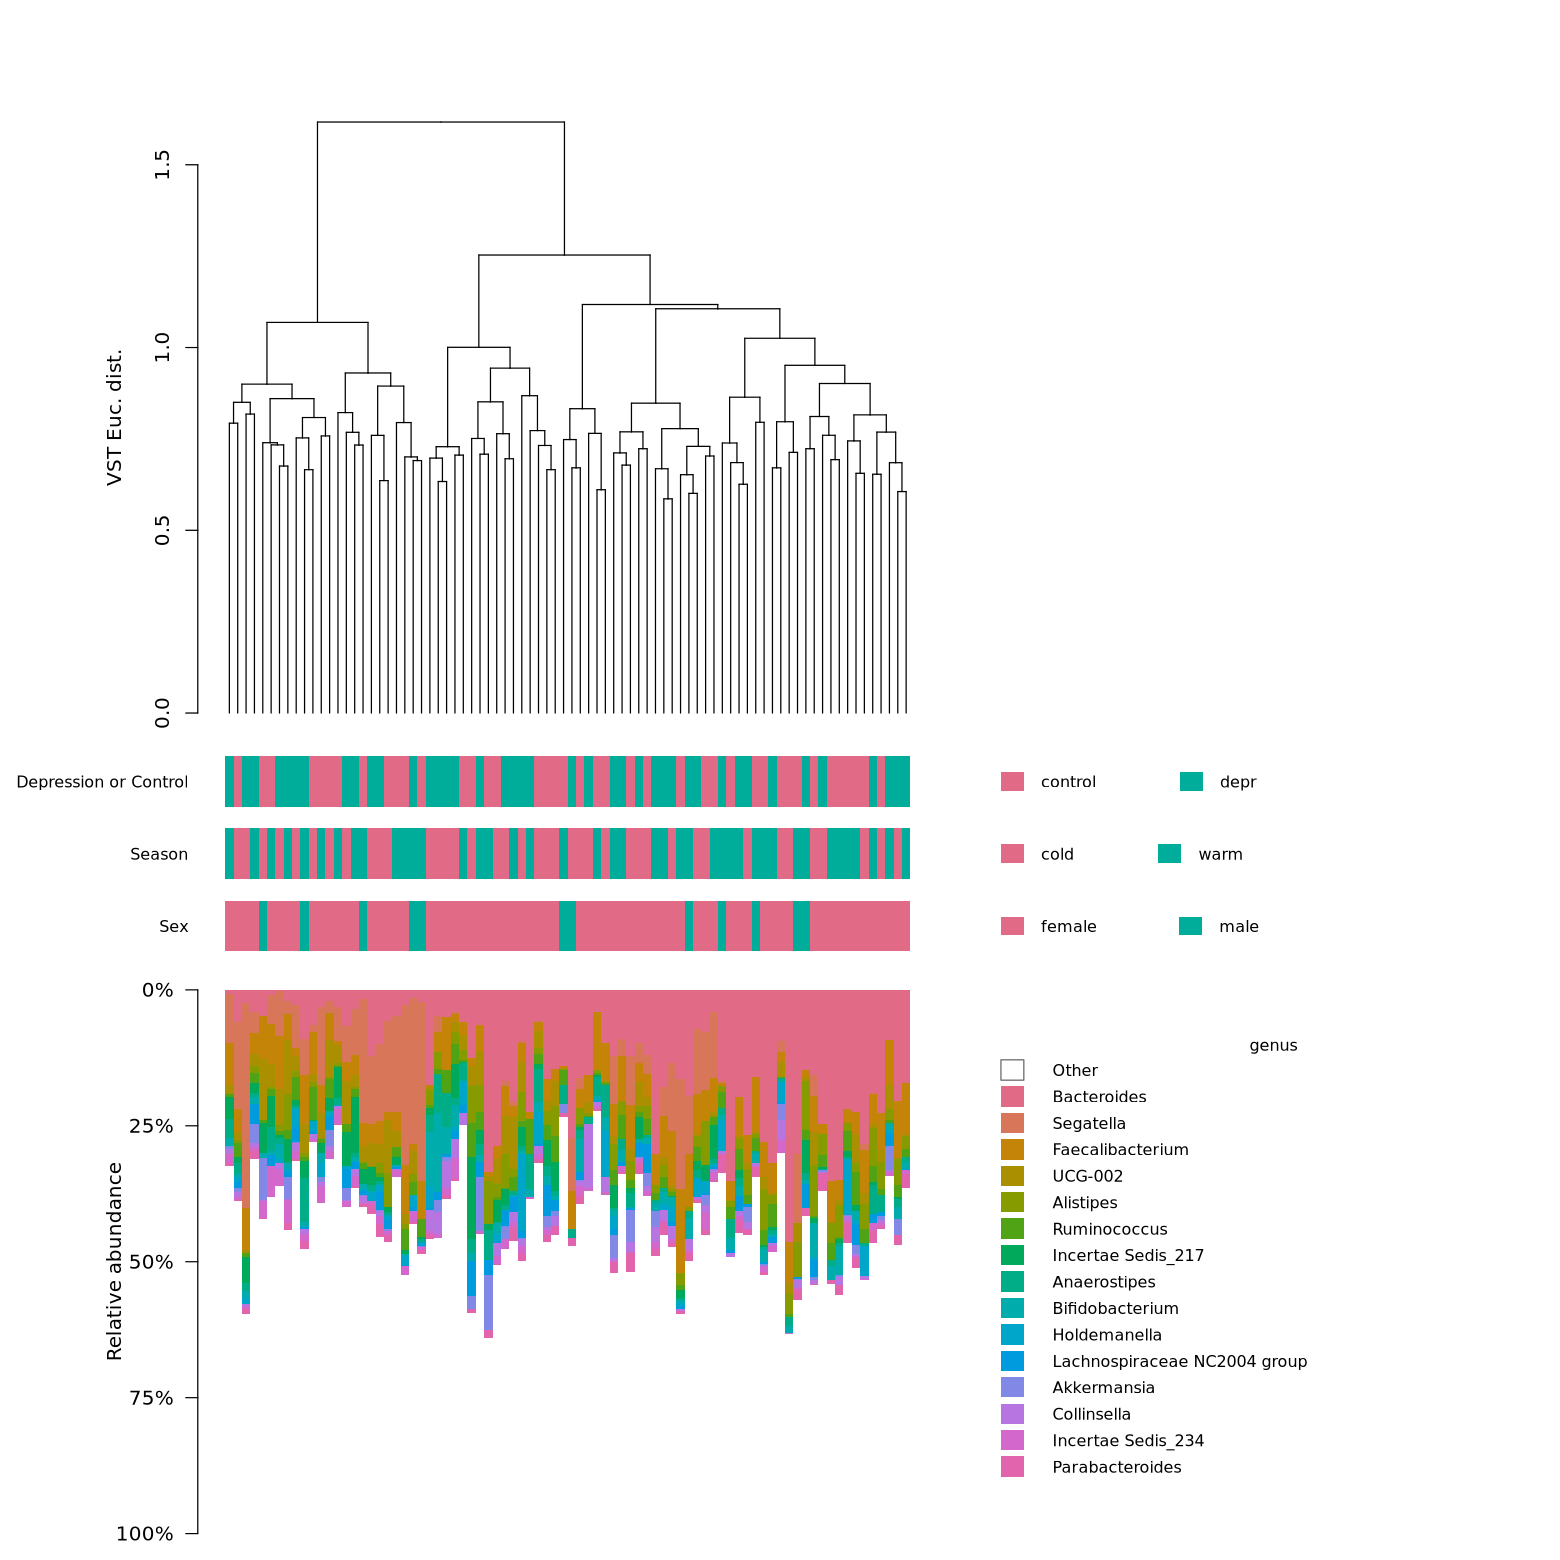

In [ ]:
options(repr.plot.width = 13, repr.plot.height = 13)
plot_dendrogram(
    bray_dist_core, ps_core_rare,
    'Depression or Control' = depr_or_control, Season = season, Sex = d_sex,
    taxa_rank = "genus", n_taxa = 15
)

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 8)
plot_pcoa(ps_core_clr, bray_dist_core, depr_or_control, legend_title="Depression vs. Control")

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': error in evaluating the argument 'object' in selecting a method for function 'sample_data': object 'ps_core_clr' not found


In [ ]:
dc_beta_bray <- betadisper(bray_dist_core, sample_data(ps_core_clr)$depr_or_control)
dc_beta_bray$group.distances |> t()

anova(dc_beta_bray, by='margin')

set.seed(08092003)
form_string <- paste("bray_dist_core", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

control,depr
0.5644687,0.5496247


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,0.004517029,0.004517029,2.031549,0.1579535
Residuals,80,0.177875227,0.002223440,NA,NA


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,0.2627566,0.010152507,0.8221356,0.910
d_sex,1,0.4214574,0.016284461,1.3186925,0.023
d_age_hc,1,0.2510705,0.009700975,0.7855712,0.948
Residual,78,24.9289972,0.963217717,NA,NA
Total,81,25.8809579,1.000000000,NA,NA
